In [1]:
import urllib.request

url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"
file_path = "the-verdict.txt"
urllib.request.urlretrieve(url, file_path)

('the-verdict.txt', <http.client.HTTPMessage at 0x1114bc050>)

In [2]:
with open(file_path, "r", encoding="utf-8") as f:
    raw_text = f.read()

print("Total no of characters: ", len(raw_text))
print(raw_text[:99])

Total no of characters:  20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [3]:
import re
text = "Hello, world. This, is a test."
result = re.split(r'(\s)', text)
result

['Hello,', ' ', 'world.', ' ', 'This,', ' ', 'is', ' ', 'a', ' ', 'test.']

In [4]:
import re
text = "Hello, world. This, is a test."
result = re.split(r'([,.]|\s)', text)
result

['Hello',
 ',',
 '',
 ' ',
 'world',
 '.',
 '',
 ' ',
 'This',
 ',',
 '',
 ' ',
 'is',
 ' ',
 'a',
 ' ',
 'test',
 '.',
 '']

In [5]:
result = [item for item in result if item.strip()]
result

['Hello', ',', 'world', '.', 'This', ',', 'is', 'a', 'test', '.']

In [6]:
text = "Hello, world. Is this-- a test?"
result = re.split(r'([,.:;?_!"()\']|--|\s)', text)
result = [item.strip() for item in result if item.strip()]
result

['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']

In [7]:
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
result = [item.strip() for item in preprocessed if item.strip()]
len(result), result[:30]

(4690,
 ['I',
  'HAD',
  'always',
  'thought',
  'Jack',
  'Gisburn',
  'rather',
  'a',
  'cheap',
  'genius',
  '--',
  'though',
  'a',
  'good',
  'fellow',
  'enough',
  '--',
  'so',
  'it',
  'was',
  'no',
  'great',
  'surprise',
  'to',
  'me',
  'to',
  'hear',
  'that',
  ',',
  'in'])

In [8]:
all_words = sorted(set(preprocessed))
vocab_size = len(all_words)
print(vocab_size)

1133


In [9]:
vocab = {token: integer for integer, token in enumerate(all_words)}
for i, item in enumerate(vocab.items()):
    print(item)
    if i >= 50:
        break
    

('', 0)
('\n', 1)
(' ', 2)
('!', 3)
('"', 4)
("'", 5)
('(', 6)
(')', 7)
(',', 8)
('--', 9)
('.', 10)
(':', 11)
(';', 12)
('?', 13)
('A', 14)
('Ah', 15)
('Among', 16)
('And', 17)
('Are', 18)
('Arrt', 19)
('As', 20)
('At', 21)
('Be', 22)
('Begin', 23)
('Burlington', 24)
('But', 25)
('By', 26)
('Carlo', 27)
('Chicago', 28)
('Claude', 29)
('Come', 30)
('Croft', 31)
('Destroyed', 32)
('Devonshire', 33)
('Don', 34)
('Dubarry', 35)
('Emperors', 36)
('Florence', 37)
('For', 38)
('Gallery', 39)
('Gideon', 40)
('Gisburn', 41)
('Gisburns', 42)
('Grafton', 43)
('Greek', 44)
('Grindle', 45)
('Grindles', 46)
('HAD', 47)
('Had', 48)
('Hang', 49)
('Has', 50)


In [10]:
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i:s for s,i in vocab.items()}

    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        return text

In [11]:
tokenizer = SimpleTokenizerV1(vocab)
text = """
It's the last he painted, you know, Mrs. Gisburn said with pardonable pride.
"""
ids = tokenizer.encode(text)
print(ids)

[59, 5, 853, 991, 605, 536, 749, 8, 1129, 599, 8, 70, 10, 41, 854, 1111, 757, 796, 10]


In [12]:
tokenizer.decode(ids)

"It' s the last he painted, you know, Mrs. Gisburn said with pardonable pride."

In [13]:
text = "Hello, do you like tea?"
# tokenizer.encode(text)

In [14]:
all_tokens = sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])
vocab = {token:integer for integer, token in enumerate(all_tokens)}
len(vocab)

1135

In [15]:
for i, item in enumerate(list(vocab.items())[-5:]):
    print(item)

('younger', 1130)
('your', 1131)
('yourself', 1132)
('<|endoftext|>', 1133)
('<|unk|>', 1134)


In [16]:
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i:s for s, i in vocab.items()}

    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)
        preprocessed = [
            item.strip() for item in preprocessed if item.strip()
        ]
        preprocessed = [
            item if item in self.str_to_int else "<|unk|>" for item in preprocessed
        ]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        text = re.sub(r'\s+([,.:;?!"()\'])', r'\1', text)
        return text

In [17]:
text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."
text = " <|endoftext|> ".join((text1, text2))
text

'Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.'

In [18]:
tokenizer = SimpleTokenizerV2(vocab)
ids = tokenizer.encode(text)
ids

[1134, 8, 358, 1129, 631, 978, 13, 1133, 58, 991, 959, 987, 725, 991, 1134, 10]

In [19]:
tokenizer.decode(ids)

'<|unk|>, do you like tea? <|endoftext|> In the sunlit terraces of the <|unk|>.'

In [20]:
!pip install tiktoken

In [21]:
import tiktoken

In [22]:
tiktoken.__version__

'0.8.0'

In [23]:
tokenizer = tiktoken.get_encoding("gpt2")

In [24]:
text = "Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace in someunknownplace"

In [25]:
ints = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
ints

[15496,
 11,
 466,
 345,
 588,
 8887,
 30,
 220,
 50256,
 554,
 262,
 4252,
 18250,
 8812,
 2114,
 286,
 262,
 20562,
 287,
 617,
 34680,
 5372]

In [26]:
strings = tokenizer.decode(ints)

In [27]:
strings

'Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace in someunknownplace'

In [28]:
with open(file_path, "r", encoding="utf-8") as f:
    raw_text = f.read()

enc_text = tokenizer.encode(raw_text)
len(enc_text)

5145

In [29]:
tokenizer.decode(enc_text[:10])

'I HAD always thought Jack Gisburn rather'

In [30]:
enc_sample = enc_text[50:]

In [31]:
context_size = 4
x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]
print(f"x: {x}")
print(f"y:      {y}")

x: [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257]


In [32]:
for i in range(1, context_size + 1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(context, "--->", desired)

[290] ---> 4920
[290, 4920] ---> 2241
[290, 4920, 2241] ---> 287
[290, 4920, 2241, 287] ---> 257


In [33]:
for i in range(1, context_size + 1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(tokenizer.decode(context), "--->", tokenizer.decode([desired]))

 and --->  established
 and established --->  himself
 and established himself --->  in
 and established himself in --->  a


In [34]:
import torch
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []
        token_ids = tokenizer.encode(txt)

        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

In [35]:
def create_dataloader_v1(txt, batch_size=4, max_length=256, 
                         stride=128, shuffle=True, drop_last=True, num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )
    return dataloader

In [36]:
with open(file_path, "r", encoding="utf-8") as f:
    raw_text = f.read()

dataloader = create_dataloader_v1(raw_text, 1, max_length=4, stride=1, shuffle=False)
data_iter = iter(dataloader)
first_batch = next(data_iter)
tokenizer.decode(first_batch[0].tolist()[0]), tokenizer.decode(first_batch[1].tolist()[0]), first_batch

('I HAD always',
 ' HAD always thought',
 [tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])])

In [37]:
dataloader = create_dataloader_v1(
    raw_text, batch_size=8, max_length=4, stride=4, shuffle=False
)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


In [38]:
input_ids = torch.tensor([2, 3, 5, 1])

In [39]:
vocab_size = 6
output_dims = 3

In [40]:
torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dims)
embedding_layer.weight

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)

In [41]:
embedding_layer(torch.tensor([3]))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)

In [42]:
embedding_layer(input_ids)

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)

In [43]:
vocab_size = 50257
output_dim = 256
token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [44]:
max_length = 4
dataloader = create_dataloader_v1(
    raw_text, batch_size=8, max_length=max_length, stride=max_length, shuffle=False
)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)

In [45]:
print("Token IDs:\n", inputs)
print("Inputs shape:\n", inputs.shape)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])
Inputs shape:
 torch.Size([8, 4])


In [46]:
token_embeddings = token_embedding_layer(inputs)
token_embeddings.shape

torch.Size([8, 4, 256])

In [47]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)
pos_embeddings = pos_embedding_layer(torch.arange(context_length))
pos_embeddings.shape

torch.Size([4, 256])

In [48]:
input_embeddings = token_embeddings + pos_embeddings
input_embeddings.shape

torch.Size([8, 4, 256])

In [49]:
import torch

inputs = torch.tensor([
    [0.43, 0.15, 0.89],
    [0.55, 0.87, 0.66],
    [0.57, 0.85, 0.64],
    [0.22, 0.58, 0.33],
    [0.77, 0.25, 0.10],
    [0.05, 0.80, 0.55]
])

In [50]:
query = inputs[1]
attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query)
attn_scores_2

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])

In [51]:
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()
print("Attention weights", attn_weights_2_tmp)
print("Sum", attn_weights_2_tmp.sum())

Attention weights tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum tensor(1.0000)


In [52]:
def softmax_naive(x):
    return torch.exp(x)/torch.exp(x).sum(dim=0)

attn_weights_2_tmp = softmax_naive(attn_scores_2)
print("Attention weights", attn_weights_2_tmp)
print("Sum", attn_weights_2_tmp.sum())

Attention weights tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum tensor(1.)


In [53]:
attn_weights_2_tmp = torch.softmax(attn_scores_2, dim=0)
print("Attention weights", attn_weights_2_tmp)
print("Sum", attn_weights_2_tmp.sum())

Attention weights tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum tensor(1.)


In [54]:
query = inputs[1]
context_vec_2 = torch.zeros(query.shape)
for i, x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2_tmp[i] * x_i
context_vec_2

tensor([0.4419, 0.6515, 0.5683])

In [55]:
attn_scores = torch.empty(6, 6)
for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i, j] = torch.dot(x_i, x_j)
attn_scores

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])

In [56]:
attn_scores = inputs @ inputs.T
attn_scores

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])

In [57]:
attn_weights = torch.softmax(attn_scores, dim=-1)
attn_weights

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])

In [58]:
attn_weights.sum(dim=1)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

In [59]:
all_context_vecs = attn_weights @ inputs
all_context_vecs

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])

In [60]:
x_2 = inputs[1]
d_in = inputs.shape[1]
d_out = 2

In [61]:
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

In [62]:
query_2 = x_2 @ W_query
key_2 = x_2 @ W_key
value_2 = x_2 @ W_value
query_2, key_2, value_2

(tensor([0.4306, 1.4551]), tensor([0.4433, 1.1419]), tensor([0.3951, 1.0037]))

In [63]:
keys = inputs @ W_key
values = inputs @ W_value
keys.shape, values.shape

(torch.Size([6, 2]), torch.Size([6, 2]))

In [64]:
keys

tensor([[0.3669, 0.7646],
        [0.4433, 1.1419],
        [0.4361, 1.1156],
        [0.2408, 0.6706],
        [0.1827, 0.3292],
        [0.3275, 0.9642]])

In [65]:
keys_2 = keys[1]
attn_score_22 = query_2.dot(keys_2)
attn_score_22

tensor(1.8524)

In [66]:
attn_scores_2 = query_2 @ keys.T
attn_scores_2

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])

In [67]:
d_k = keys.shape[-1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k ** 0.5, dim=-1)
attn_weights_2

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])

In [68]:
context_vec_2 = attn_weights_2 @ values
context_vec_2

tensor([0.3061, 0.8210])

In [69]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        keys = x @ self.W_key
        queries = x @ self.W_query
        values = x @ self.W_value
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1] ** 0.5, dim=-1
        )
        context_vec = attn_weights @ values
        return context_vec

In [70]:
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
sa_v1(inputs)

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)

In [71]:
class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1] ** 0.5, dim=-1
        )
        context_vec = attn_weights @ values
        return context_vec

In [72]:
torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
sa_v2(inputs)

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)

In [73]:
sa_v2.W_query.weight.T

tensor([[ 0.3161, -0.1683],
        [ 0.4568, -0.3379],
        [ 0.5118, -0.0918]], grad_fn=<PermuteBackward0>)

In [74]:
inputs.shape

torch.Size([6, 3])

In [75]:
nn.Parameter(sa_v2.W_query.weight.T)

Parameter containing:
tensor([[ 0.3161, -0.1683],
        [ 0.4568, -0.3379],
        [ 0.5118, -0.0918]], requires_grad=True)

In [76]:
context_length

4

In [77]:
torch.ones(4, 4)

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

In [78]:
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs)
attn_scores = queries @ keys.T
attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5, dim=-1)
attn_weights

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)

In [79]:
context_length = attn_weights.shape[0]
context_length

6

In [80]:
attn_weights.shape

torch.Size([6, 6])

In [81]:
attn_weights[0]

tensor([0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
       grad_fn=<SelectBackward0>)

In [82]:
mask_simple = torch.tril(torch.ones(context_length, context_length))
mask_simple

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])

In [83]:
masked_simple = attn_weights * mask_simple
masked_simple

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)

In [84]:
row_sums = masked_simple.sum(dim=-1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
masked_simple_norm

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)

In [85]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
mask

tensor([[0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0.]])

In [86]:
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
masked

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)

In [87]:
attn_weights = torch.softmax(masked / keys.shape[-1] ** 0.5, dim=-1)
attn_weights

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)

In [88]:
torch.manual_seed(123)
dropout = nn.Dropout(0.5)
example = torch.ones(6, 6)
dropout(example), example

(tensor([[2., 2., 0., 2., 2., 0.],
         [0., 0., 0., 2., 0., 2.],
         [2., 2., 2., 2., 0., 2.],
         [0., 2., 2., 0., 0., 2.],
         [0., 2., 0., 2., 0., 2.],
         [0., 2., 2., 2., 2., 0.]]),
 tensor([[1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.]]))

In [89]:
torch.manual_seed(123)
dropout(attn_weights)

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7599, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4921, 0.4925, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3966, 0.0000, 0.3775, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.3331, 0.3084, 0.3331, 0.0000]],
       grad_fn=<MulBackward0>)

In [90]:
batch = torch.stack((inputs, inputs), dim=0)
batch.shape

torch.Size([2, 6, 3])

In [91]:
batch

tensor([[[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]],

        [[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]]])

In [92]:
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.transpose(1, 2)
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf
        )
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1] ** 0.5, dim=-1
        )
        attn_weights = self.dropout(attn_weights)
        context_vec = attn_weights @ values
        return context_vec

In [93]:
torch.manual_seed(123)
context_length = batch.shape[1]
ca = CausalAttention(d_in, d_out, context_length, 0.0)
context_vecs = ca(batch)
context_vecs.shape

torch.Size([2, 6, 2])

In [94]:
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias) for _ in range(num_heads)]
        )

    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)

In [95]:
torch.manual_seed(123)
context_length = batch.shape[1]
d_in, d_out = 3, 2
mha = MultiHeadAttentionWrapper(
    d_in, d_out, context_length, 0.0, num_heads=2
)
context_vecs = mha(batch)

context_vecs, context_vecs.shape

(tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
          [-0.5874,  0.0058,  0.5891,  0.3257],
          [-0.6300, -0.0632,  0.6202,  0.3860],
          [-0.5675, -0.0843,  0.5478,  0.3589],
          [-0.5526, -0.0981,  0.5321,  0.3428],
          [-0.5299, -0.1081,  0.5077,  0.3493]],
 
         [[-0.4519,  0.2216,  0.4772,  0.1063],
          [-0.5874,  0.0058,  0.5891,  0.3257],
          [-0.6300, -0.0632,  0.6202,  0.3860],
          [-0.5675, -0.0843,  0.5478,  0.3589],
          [-0.5526, -0.0981,  0.5321,  0.3428],
          [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>),
 torch.Size([2, 6, 4]))

In [96]:
torch.manual_seed(123)
context_length = batch.shape[1]
d_in, d_out = 3, 1
mha = MultiHeadAttentionWrapper(
    d_in, d_out, context_length, 0.0, num_heads=2
)
context_vecs = mha(batch)

context_vecs, context_vecs.shape

(tensor([[[-0.5740,  0.2216],
          [-0.7320,  0.0155],
          [-0.7774, -0.0546],
          [-0.6979, -0.0817],
          [-0.6538, -0.0957],
          [-0.6424, -0.1065]],
 
         [[-0.5740,  0.2216],
          [-0.7320,  0.0155],
          [-0.7774, -0.0546],
          [-0.6979, -0.0817],
          [-0.6538, -0.0957],
          [-0.6424, -0.1065]]], grad_fn=<CatBackward0>),
 torch.Size([2, 6, 2]))

In [97]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out nust be divisible by num_heads"
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)
        attn_scores = queries @ keys.transpose(2, 3)
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1] ** 0.5, dim=-1
        )
        attn_weights = self.dropout(attn_weights)
        context_vec = (attn_weights @ values).transpose(1, 2)
        context_vec = context_vec.contiguous().view(
            b, num_tokens, self.d_out
        )
        context_vec = self.out_proj(context_vec)
        return context_vec

In [98]:
torch.manual_seed(123)
batch_size, context_length, d_in = batch.shape
d_out = 2
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)
context_vecs, context_vecs.shape

(tensor([[[0.3190, 0.4858],
          [0.2943, 0.3897],
          [0.2856, 0.3593],
          [0.2693, 0.3873],
          [0.2639, 0.3928],
          [0.2575, 0.4028]],
 
         [[0.3190, 0.4858],
          [0.2943, 0.3897],
          [0.2856, 0.3593],
          [0.2693, 0.3873],
          [0.2639, 0.3928],
          [0.2575, 0.4028]]], grad_fn=<ViewBackward0>),
 torch.Size([2, 6, 2]))

In [99]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

In [100]:
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    def forward(self, x):
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()

    def forward(self, x):
        return x

In [101]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
batch

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

In [102]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
logits.shape, logits

(torch.Size([2, 4, 50257]),
 tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
          [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
          [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
          [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],
 
         [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
          [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
          [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
          [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
        grad_fn=<UnsafeViewBackward0>))

In [103]:
torch.manual_seed(123)
batch_example = torch.randn(2, 5)
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
out

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)

In [104]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
mean, var

(tensor([[0.1324],
         [0.2170]], grad_fn=<MeanBackward1>),
 tensor([[0.0231],
         [0.0398]], grad_fn=<VarBackward0>))

In [105]:
out_norm = (out - mean) / torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
out_norm, mean, var

(tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
         [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
        grad_fn=<DivBackward0>),
 tensor([[-5.9605e-08],
         [ 1.9868e-08]], grad_fn=<MeanBackward1>),
 tensor([[1.0000],
         [1.0000]], grad_fn=<VarBackward0>))

In [106]:
torch.set_printoptions(sci_mode=False)
mean, var

(tensor([[    -0.0000],
         [     0.0000]], grad_fn=<MeanBackward1>),
 tensor([[1.0000],
         [1.0000]], grad_fn=<VarBackward0>))

In [107]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [108]:
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, keepdim=True, unbiased=False)
mean, var, out_ln

(tensor([[    -0.0000],
         [     0.0000]], grad_fn=<MeanBackward1>),
 tensor([[1.0000],
         [1.0000]], grad_fn=<VarBackward0>),
 tensor([[ 0.5528,  1.0693, -0.0223,  0.2656, -1.8654],
         [ 0.9087, -1.3767, -0.9564,  1.1304,  0.2940]], grad_fn=<AddBackward0>))

In [109]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0/torch.pi)) * (x + 0.044715 * torch.pow(x, 3))))

In [110]:
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()


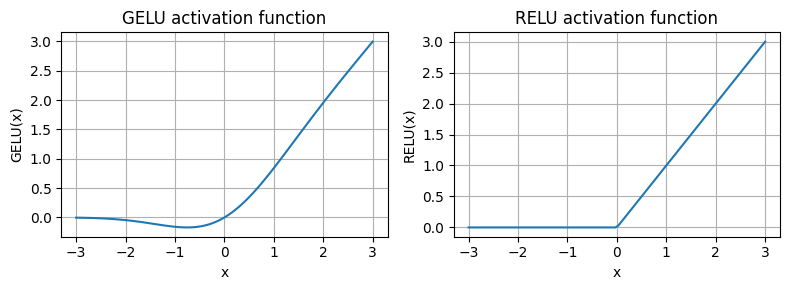

In [111]:
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "RELU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
plt.tight_layout()
plt.show()

In [112]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])
        )

    def forward(self, x):
        return self.layers(x)

In [113]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)
out = ffn(x)
out.shape

torch.Size([2, 3, 768])

In [114]:
out, x

(tensor([[[ 0.1238,  0.0457,  0.0939,  ...,  0.1107,  0.0167, -0.1992],
          [ 0.1574, -0.0282,  0.0049,  ...,  0.0026,  0.1120, -0.1075],
          [ 0.1184, -0.0052,  0.0839,  ...,  0.1662,  0.0112, -0.1685]],
 
         [[ 0.1302,  0.0630,  0.1050,  ...,  0.1439,  0.0562, -0.1128],
          [ 0.1249, -0.0073,  0.1022,  ...,  0.0417,  0.0381, -0.0828],
          [ 0.0494,  0.0654,  0.0347,  ...,  0.0701,  0.0793, -0.1810]]],
        grad_fn=<ViewBackward0>),
 tensor([[[0.0351, 0.0028, 0.6470,  ..., 0.5897, 0.8112, 0.1335],
          [0.2758, 0.6665, 0.3312,  ..., 0.7204, 0.3365, 0.9016],
          [0.7622, 0.4008, 0.4706,  ..., 0.4857, 0.9844, 0.0499]],
 
         [[0.8761, 0.8123, 0.2511,  ..., 0.8113, 0.3147, 0.6469],
          [0.9920, 0.7436, 0.7393,  ..., 0.8690, 0.1667, 0.4374],
          [0.8999, 0.0747, 0.1878,  ..., 0.0586, 0.7915, 0.8741]]]))

In [115]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

In [116]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)
model_without_shortcut

ExampleDeepNeuralNetwork(
  (layers): ModuleList(
    (0-3): 4 x Sequential(
      (0): Linear(in_features=3, out_features=3, bias=True)
      (1): GELU()
    )
    (4): Sequential(
      (0): Linear(in_features=3, out_features=1, bias=True)
      (1): GELU()
    )
  )
)

In [117]:
def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.]])
    loss = nn.MSELoss()
    loss = loss(output, target)
    loss.backward()
    for name, param in model.named_parameters():
        if "weight" in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [118]:
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041071094573
layers.3.0.weight has gradient mean of 0.0013988735154271126
layers.4.0.weight has gradient mean of 0.005049645435065031


In [119]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258540630340576


In [120]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x

In [121]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

x.shape, output.shape

(torch.Size([2, 4, 768]), torch.Size([2, 4, 768]))

In [122]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [123]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
out = model(batch)
batch, out, out.shape, batch.shape

(tensor([[6109, 3626, 6100,  345],
         [6109, 1110, 6622,  257]]),
 tensor([[[ 0.3613,  0.4223, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
          [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
          [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
          [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],
 
         [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
          [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
          [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
          [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
        grad_fn=<UnsafeViewBackward0>),
 torch.Size([2, 4, 50257]),
 torch.Size([2, 4]))

In [124]:
keys = torch.argmax(torch.softmax(out, dim=-1), dim=-1)

In [125]:
keys

tensor([[27595,  2463, 35303, 20860],
        [37911, 30882, 19280, 26217]])

In [126]:
tokenizer.decode(keys[0].tolist())

' UE compan sidewayscommunications'

In [127]:
total_params = sum(p.numel() for p in model.parameters())
total_params

163009536

In [128]:
model.tok_emb.weight.shape, model.out_head.weight.shape

(torch.Size([50257, 768]), torch.Size([50257, 768]))

In [129]:
total_params_gpt2 = (
    total_params - sum(p.numel() for p in model.out_head.parameters())
)

In [130]:
total_params_gpt2

124412160

In [131]:
total_size_bytes = total_params * 4
total_size_mb = total_size_bytes / (1024 * 1024)
total_size_mb

621.83203125

In [132]:
print(tokenizer.decode(torch.argmax(torch.softmax(out[:, -1, :], dim=-1), dim=-1).tolist()))

communications casts


In [133]:
tokenizer.decode(batch[0].tolist())

'Every effort moves you'

In [134]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        print(idx.shape)
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

In [135]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
encoded_tensor.shape, encoded_tensor

encoded: [15496, 11, 314, 716]


(torch.Size([1, 4]), tensor([[15496,    11,   314,   716]]))

In [136]:
tokenizer.decode(encoded_tensor[0].tolist())

'Hello, I am'

In [137]:
model.eval()
out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)
out

torch.Size([1, 4])
torch.Size([1, 5])
torch.Size([1, 6])
torch.Size([1, 7])
torch.Size([1, 8])
torch.Size([1, 9])


tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])

In [138]:
tokenizer.decode(out[0].tolist())

'Hello, I am Featureiman Byeswickattribute argue'

In [139]:
list(model.parameters())

[Parameter containing:
 tensor([[     0.3374,     -0.1778,     -0.3035,  ...,     -0.3181,
              -1.3936,      0.5226],
         [     0.2579,      0.3420,     -0.8168,  ...,     -0.4098,
               0.4978,     -0.3721],
         [     0.7957,      0.5350,      0.9427,  ...,     -1.0749,
               0.0955,     -1.4138],
         ...,
         [    -0.7128,     -0.5019,      1.4119,  ...,     -0.1498,
              -0.4898,     -1.0620],
         [     2.0646,      1.1190,      0.3849,  ...,     -0.7202,
              -0.5570,      0.9864],
         [     0.0011,     -0.7532,     -0.1792,  ...,     -0.3244,
               0.2606,      0.5889]], requires_grad=True),
 Parameter containing:
 tensor([[ 0.8769,  0.2550,  0.8441,  ..., -1.0354,  1.3085,  1.7957],
         [-1.0029,  0.0995,  1.2459,  ...,  1.5453, -0.1126, -1.5197],
         [ 1.3317,  0.7561,  0.9077,  ...,  0.0830,  1.8336, -2.2225],
         ...,
         [-0.1055, -1.1941, -1.1472,  ..., -1.4544,  0.2918, 

In [140]:
import torch

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [141]:
import tiktoken

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

token_ids_to_text(token_ids, tokenizer)

torch.Size([1, 4])
torch.Size([1, 5])
torch.Size([1, 6])
torch.Size([1, 7])
torch.Size([1, 8])
torch.Size([1, 9])
torch.Size([1, 10])
torch.Size([1, 11])
torch.Size([1, 12])
torch.Size([1, 13])


'Every effort moves you rentingetic wasnم refres RexMeCHicular stren'

In [142]:
inputs = torch.tensor([
    [16833, 3636, 6100],
    [40, 1107, 588]
])
inputs

tensor([[16833,  3636,  6100],
        [   40,  1107,   588]])

In [143]:
targets = torch.tensor([
    [3626, 6100, 345],
    [1107, 588, 11311]
])
targets

tensor([[ 3626,  6100,   345],
        [ 1107,   588, 11311]])

In [144]:
with torch.no_grad():
    logits = model(inputs)
probas = torch.softmax(logits, dim=-1)
probas.shape

torch.Size([2, 3, 50257])

In [145]:
torch.argmax(probas[:,-1,:], dim=-1, keepdim=True)

tensor([[42826],
        [41751]])

In [146]:
tokenizer.decode([42826])

'Netflix'

In [147]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
token_ids

tensor([[[16657],
         [ 7824],
         [42826]],

        [[49906],
         [29669],
         [41751]]])

In [148]:
token_ids_to_text(targets[0], tokenizer)

' effort moves you'

In [149]:
token_ids_to_text(token_ids[0].flatten(), tokenizer)

' Armed APINetflix'

In [150]:
p1 = probas[0, [0, 1, 2], targets[0]]

In [151]:
p2 = probas[1, [0, 1, 2], targets[1]]

In [152]:
log_probas = torch.log(torch.cat((p1, p2)))
log_probas

tensor([ -9.5042,  -9.9563, -11.3954, -11.4798,  -9.7764, -12.2561])

In [153]:
avg_log_probas = torch.mean(log_probas)

In [154]:
avg_log_probas

tensor(-10.7280)

In [155]:
neg_avg_log_probas = -1 * avg_log_probas
neg_avg_log_probas

tensor(10.7280)

In [156]:
logits.shape, targets.shape

(torch.Size([2, 3, 50257]), torch.Size([2, 3]))

In [157]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()
logits_flat.shape, targets_flat.shape

(torch.Size([6, 50257]), torch.Size([6]))

In [158]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
loss

tensor(10.7280)

In [159]:
perplexity = torch.exp(loss)
perplexity

tensor(45616.6602)

In [160]:
file_path

'the-verdict.txt'

In [161]:
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

text_data[:10]

'I HAD alwa'

In [162]:
len(text_data), len(tokenizer.encode(text_data))

(20479, 5145)

In [163]:
train_ratio = 0.9
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [164]:
torch.manual_seed(123)
train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [165]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])


In [166]:
print("Validation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [281]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )
    return loss

In [282]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break

    return total_loss / num_batches

In [169]:
device = "mps" if torch.mps.is_available() else "cpu"
model.to(device)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss", train_loss)
print("Val loss", val_loss)

Training loss 10.98758316040039
Val loss 10.98110580444336


In [170]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, 
                       num_epochs, eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1
    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(
                    f"Ep {epoch+1} (Step {global_step:06d}): "
                    f" Train loss {train_loss:.3f}"
                    f" Val loss {val_loss:.3f}"
                )
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )
    return train_losses, val_losses, track_tokens_seen

In [171]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [172]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded, max_new_tokens=50,
            context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

In [173]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004, weight_decay=0.1
)
num_epochs = 15
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000):  Train loss 9.817 Val loss 9.924
Ep 1 (Step 000005):  Train loss 8.066 Val loss 8.332
torch.Size([1, 4])
torch.Size([1, 5])
torch.Size([1, 6])
torch.Size([1, 7])
torch.Size([1, 8])
torch.Size([1, 9])
torch.Size([1, 10])
torch.Size([1, 11])
torch.Size([1, 12])
torch.Size([1, 13])
torch.Size([1, 14])
torch.Size([1, 15])
torch.Size([1, 16])
torch.Size([1, 17])
torch.Size([1, 18])
torch.Size([1, 19])
torch.Size([1, 20])
torch.Size([1, 21])
torch.Size([1, 22])
torch.Size([1, 23])
torch.Size([1, 24])
torch.Size([1, 25])
torch.Size([1, 26])
torch.Size([1, 27])
torch.Size([1, 28])
torch.Size([1, 29])
torch.Size([1, 30])
torch.Size([1, 31])
torch.Size([1, 32])
torch.Size([1, 33])
torch.Size([1, 34])
torch.Size([1, 35])
torch.Size([1, 36])
torch.Size([1, 37])
torch.Size([1, 38])
torch.Size([1, 39])
torch.Size([1, 40])
torch.Size([1, 41])
torch.Size([1, 42])
torch.Size([1, 43])
torch.Size([1, 44])
torch.Size([1, 45])
torch.Size([1, 46])
torch.Size([1, 47])
torch.Size([1, 48])


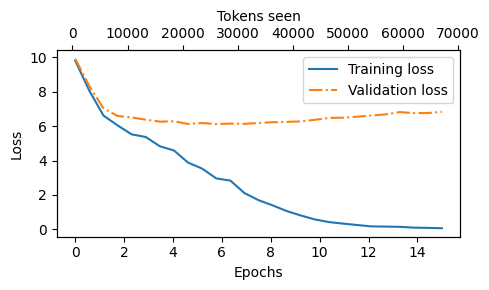

In [174]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [175]:
model.to("cpu")
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [176]:
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(model=model, 
                                idx=text_to_token_ids("Every effort moves you", tokenizer),
                                max_new_tokens=25,
                                context_size=GPT_CONFIG_124M["context_length"]
                                )
print(token_ids_to_text(token_ids, tokenizer))

torch.Size([1, 4])
torch.Size([1, 5])
torch.Size([1, 6])
torch.Size([1, 7])
torch.Size([1, 8])
torch.Size([1, 9])
torch.Size([1, 10])
torch.Size([1, 11])
torch.Size([1, 12])
torch.Size([1, 13])
torch.Size([1, 14])
torch.Size([1, 15])
torch.Size([1, 16])
torch.Size([1, 17])
torch.Size([1, 18])
torch.Size([1, 19])
torch.Size([1, 20])
torch.Size([1, 21])
torch.Size([1, 22])
torch.Size([1, 23])
torch.Size([1, 24])
torch.Size([1, 25])
torch.Size([1, 26])
torch.Size([1, 27])
torch.Size([1, 28])
Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




In [177]:
vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8
}
inverse_vocab = {v:k for k,v in vocab.items()}

In [178]:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

In [179]:
probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()
inverse_vocab[next_token_id]

'forward'

In [180]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


In [181]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")
print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


In [182]:
def softmax_with_temprature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

In [183]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top pos", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top pos tensor([3, 7, 0])


In [184]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")),
    other=next_token_logits
)
new_logits

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])

In [185]:
topk_probas = torch.softmax(new_logits, dim=0)
topk_probas

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])

In [186]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:,-context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:,-1,:]
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:,-1]
            logits = torch.where(
                logits < min_val,
                torch.tensor(float("-inf")).to(logits.device),
                logits
            )
        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        if idx_next == eos_id:
            break
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

In [187]:
torch.manual_seed(123)
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)
token_ids_to_text(token_ids, tokenizer)

'Every effort moves you?""Money\'s surprise, a cheap genius--though a good fellow enough'

In [188]:
torch.save(model.state_dict(), "model1.pth")

In [189]:
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model1.pth", map_location=device))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [190]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict()
}, "model_and_optimizer.pth")

In [191]:
checkpoint = torch.load("model_and_optimizer.pth", map_location=device)
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [192]:
!pip install tensorflow tqdm

In [193]:
import urllib.request
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)

filename = url.split("/")[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x4f504bc50>)

In [194]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


In [195]:
print("Settings", settings)
print("Parameter dictionary", params.keys())

Settings {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [196]:
params["wte"], params["wte"].shape

(array([[-0.11010301, -0.03926672,  0.03310751, ..., -0.1363697 ,
          0.01506208,  0.04531523],
        [ 0.04034033, -0.04861503,  0.04624869, ...,  0.08605453,
          0.00253983,  0.04318958],
        [-0.12746179,  0.04793796,  0.18410145, ...,  0.08991534,
         -0.12972379, -0.08785918],
        ...,
        [-0.04453601, -0.05483596,  0.01225674, ...,  0.10435229,
          0.09783269, -0.06952604],
        [ 0.1860082 ,  0.01665728,  0.04611587, ..., -0.09625227,
          0.07847701, -0.02245961],
        [ 0.05135201, -0.02768905,  0.0499369 , ...,  0.00704835,
          0.15519823,  0.12067825]], dtype=float32),
 (50257, 768))

In [197]:
model_configs = {
    "gpt2-small (124M)": {
        "emb_dim": 768,
        "n_layers": 12,
        "n_heads": 12
    },
    "gpt2-medium (355M)": {
        "emb_dim": 1024,
        "n_layers": 24,
        "n_heads": 16
    },
    "gpt2-large (774M)": {
        "emb_dim": 1280,
        "n_layers": 36,
        "n_heads": 20
    },
    "gpt2-xl (1558M)": {
        "emb_dim": 1600,
        "n_layers": 48,
        "n_heads": 25
    }
}

In [198]:
model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])

In [199]:
NEW_CONFIG.update({"context_length": 1024})

In [200]:
NEW_CONFIG.update({"qkv_bias": True})

In [201]:
gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [202]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, "
                         f"Right: {right.shape}"
                        )
    return torch.nn.Parameter(torch.tensor(right))

In [203]:
params["blocks"][0].keys()

dict_keys(['attn', 'ln_1', 'ln_2', 'mlp'])

In [204]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params["wpe"])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params["wte"])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split((params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split((params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(gpt.trf_blocks[b].att.out_proj.weight, params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(gpt.trf_blocks[b].att.out_proj.bias, params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(gpt.trf_blocks[b].ff.layers[0].weight, params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(gpt.trf_blocks[b].ff.layers[0].bias, params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(gpt.trf_blocks[b].ff.layers[2].weight, params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(gpt.trf_blocks[b].ff.layers[2].bias, params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(gpt.trf_blocks[b].norm1.scale, params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(gpt.trf_blocks[b].norm1.shift, params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(gpt.trf_blocks[b].norm2.scale, params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(gpt.trf_blocks[b].norm2.shift, params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])
        
        

In [205]:
load_weights_into_gpt(gpt, params)
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [206]:
torch.manual_seed(123)
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)
token_ids_to_text(token_ids, tokenizer)

'Every effort moves you toward more efficient and efficient processes, like in the car\'s oil and gas operation," the study said. To see if that'

In [207]:
import urllib.request
import zipfile
import os
from pathlib import Path

url = "http://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction")
        return

    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

In [208]:
download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection/SMSSpamCollection.tsv already exists. Skipping download and extraction


In [209]:
import pandas as pd
df = pd.read_csv(data_file_path, sep="\t", header=None, names=["label", "Text"])
df

,label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [210]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [211]:
def create_balanced_dataset(df):
    num_spam = df[df["label"] == "spam"].shape[0]
    ham_subset = df[df["label"] == "ham"].sample(
        num_spam, random_state=123
    )
    balanced_df = pd.concat([
        ham_subset, df[df["label"] == "spam"]
    ])
    return balanced_df

In [212]:
balanced_df = create_balanced_dataset(df)
balanced_df["label"].value_counts()

label
ham     747
spam    747
Name: count, dtype: int64

In [213]:
balanced_df["label"] = balanced_df["label"].map({"ham": 0, "spam": 1})

In [214]:
def random_split(df, train_frac, validation_frac):
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]
    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)

In [215]:
train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

In [216]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})

[50256]

In [217]:
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            self.encoded_texts = [
                encoded_text[:self.max_length] for encoded_text in self.encoded_texts
            ]

        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length

In [218]:
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

train_dataset.max_length

120

In [219]:
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

In [220]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False
)

In [221]:
for input_batch, target_batch in train_loader:
    pass

input_batch.shape, target_batch.shape

(torch.Size([8, 120]), torch.Size([8]))

In [222]:
len(train_loader), len(test_loader), len(val_loader)

(130, 38, 19)

In [223]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"
BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [224]:
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [225]:
text_1 = "Every effort moves you"
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)
token_ids_to_text(token_ids, tokenizer)

torch.Size([1, 4])
torch.Size([1, 5])
torch.Size([1, 6])
torch.Size([1, 7])
torch.Size([1, 8])
torch.Size([1, 9])
torch.Size([1, 10])
torch.Size([1, 11])
torch.Size([1, 12])
torch.Size([1, 13])
torch.Size([1, 14])
torch.Size([1, 15])
torch.Size([1, 16])
torch.Size([1, 17])
torch.Size([1, 18])


'Every effort moves you forward.\n\nThe first step is to understand the importance of your work'

In [226]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to recieve $100 cash or a $2000 award.'"
)
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

torch.Size([1, 39])
torch.Size([1, 40])
torch.Size([1, 41])
torch.Size([1, 42])
torch.Size([1, 43])
torch.Size([1, 44])
torch.Size([1, 45])
torch.Size([1, 46])
torch.Size([1, 47])
torch.Size([1, 48])
torch.Size([1, 49])
torch.Size([1, 50])
torch.Size([1, 51])
torch.Size([1, 52])
torch.Size([1, 53])
torch.Size([1, 54])
torch.Size([1, 55])
torch.Size([1, 56])
torch.Size([1, 57])
torch.Size([1, 58])
torch.Size([1, 59])
torch.Size([1, 60])
torch.Size([1, 61])
Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to recieve $100 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


In [227]:
model

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [228]:
for param in model.parameters():
    param.requires_grad = False

In [229]:
torch.manual_seed(123)
num_classes = 2
model.out_head = torch.nn.Linear(
    in_features=BASE_CONFIG["emb_dim"],
    out_features=num_classes
)

In [230]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

In [231]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
inputs, inputs.shape

(tensor([[5211,  345,  423,  640]]), torch.Size([1, 4]))

In [232]:
with torch.no_grad():
    outputs = model(inputs)
outputs, outputs.shape

(tensor([[[-1.5854,  0.9904],
          [-3.7235,  7.4548],
          [-2.2661,  6.6049],
          [-3.5983,  3.9902]]]),
 torch.Size([1, 4, 2]))

In [233]:
outputs[:,-1,:]

tensor([[-3.5983,  3.9902]])

In [234]:
probas = torch.softmax(outputs[:,-1,:], dim=-1)
label = torch.argmax(probas)
label.item()

1

In [235]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:,-1,:]

            predicted_labels = torch.argmax(logits, dim=-1)
            num_examples += predicted_labels.shape[0]
            correct_predictions += (
                (predicted_labels == target_batch).sum().item()
            )
        else:
            break
    return correct_predictions / num_examples

In [236]:
model.to(device)
torch.manual_seed(123)
train_accuracy = calc_accuracy_loader(
    train_loader, model, device, num_batches=10
)

val_accuracy = calc_accuracy_loader(
    val_loader, model, device, num_batches=10
)

test_accuracy = calc_accuracy_loader(
    test_loader, model, device, num_batches=10
)

train_accuracy, val_accuracy, test_accuracy

(0.4625, 0.45, 0.4875)

In [237]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)[:,-1,:]
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

In [238]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [239]:
with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=5
    )
    test_loss = calc_loss_loader(
        test_loader, model, device, num_batches=5
    )

train_loss, val_loss, test_loss

(2.4529502034187316, 2.5829514265060425, 2.3219629287719727)

In [240]:
def train_classifier_simple(
  model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter  
):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1
    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()
            optimizer.step()
            examples_seen += input_batch.shape[0]
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch + 1} (Step {global_step:06d}): ", f"Train loss {train_loss:.3f}", f"Val loss {val_loss:.3f}")

        train_accuracy = calc_accuracy_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_accuracy = calc_accuracy_loader(
            val_loader, model, device, num_batches=eval_iter
        )

        print(f"Training accuracy: {train_accuracy * 100:.2f}% | Validation accuracy: {val_accuracy * 100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

In [241]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss
    

In [242]:
import time
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5

train_losses, val_losses, train_acs, val_acs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device, num_epochs=num_epochs, eval_freq=50, eval_iter=5
)

end_time = time.time()
exec_time = (end_time - start_time) / 60
print(exec_time)

Ep 1 (Step 000000):  Train loss 2.153 Val loss 2.392
Ep 1 (Step 000050):  Train loss 0.617 Val loss 0.637
Ep 1 (Step 000100):  Train loss 0.523 Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150):  Train loss 0.561 Val loss 0.489
Ep 2 (Step 000200):  Train loss 0.419 Val loss 0.397
Ep 2 (Step 000250):  Train loss 0.409 Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300):  Train loss 0.333 Val loss 0.320
Ep 3 (Step 000350):  Train loss 0.340 Val loss 0.306
Training accuracy: 90.00% | Validation accuracy: 90.00%
Ep 4 (Step 000400):  Train loss 0.136 Val loss 0.200
Ep 4 (Step 000450):  Train loss 0.153 Val loss 0.132
Ep 4 (Step 000500):  Train loss 0.222 Val loss 0.137
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 5 (Step 000550):  Train loss 0.207 Val loss 0.143
Ep 5 (Step 000600):  Train loss 0.083 Val loss 0.074
Training accuracy: 100.00% | Validation accuracy: 97.50%
0.8591548482577006


In [243]:
model.to(device)
torch.manual_seed(123)
train_accuracy = calc_accuracy_loader(
    train_loader, model, device
)

val_accuracy = calc_accuracy_loader(
    val_loader, model, device
)

test_accuracy = calc_accuracy_loader(
    test_loader, model, device
)

train_accuracy, val_accuracy, test_accuracy

(0.9721153846153846, 0.9731543624161074, 0.9566666666666667)

In [244]:
text_2

"Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to recieve $100 cash or a $2000 award.'"

In [245]:
model.to("cpu")
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to recieve $100 cash or a $2000 award.'"
)
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)
token_ids.shape

torch.Size([1, 39])
torch.Size([1, 40])
torch.Size([1, 41])
torch.Size([1, 42])
torch.Size([1, 43])
torch.Size([1, 44])
torch.Size([1, 45])
torch.Size([1, 46])
torch.Size([1, 47])
torch.Size([1, 48])
torch.Size([1, 49])
torch.Size([1, 50])
torch.Size([1, 51])
torch.Size([1, 52])
torch.Size([1, 53])
torch.Size([1, 54])
torch.Size([1, 55])
torch.Size([1, 56])
torch.Size([1, 57])
torch.Size([1, 58])
torch.Size([1, 59])
torch.Size([1, 60])
torch.Size([1, 61])


torch.Size([1, 62])

In [246]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()
    input_ids = tokenizer.encode(text)
    model.to(device)
    supported_context_length = model.pos_emb.weight.shape[1]
    input_ids = input_ids[:min(max_length, supported_context_length)]
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0)
    input_tensor.to(device)
    with torch.no_grad():
        logits = model(input_tensor)[:,-1,:]
    predicted_label = torch.argmax(logits, dim=-1).item()
    return predicted_label

In [247]:
classify_review(text_1, model, tokenizer, device, 100)

0

In [248]:
classify_review(text_2, model, tokenizer, device, 100)

1

In [249]:
text_1

'Every effort moves you'

In [250]:
text_2

"Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to recieve $100 cash or a $2000 award.'"

In [251]:
torch.save(model.state_dict(), "review_classifier.pth")

In [252]:
model.to("cpu")

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [253]:
import json
import os
import urllib

def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    else:
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()

    with open(file_path, "r") as file:
        data = json.load(file)

    return data

file_path = "instruction-data.json"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/instruction-data.json"

data = download_and_load_file(file_path, url)
len(data)

1100

In [254]:
data[50]

{'instruction': 'Identify the correct spelling of the following word.',
 'input': 'Ocassion',
 'output': "The correct spelling is 'Occasion.'"}

In [255]:
data[999]

{'instruction': "What is an antonym of 'complicated'?",
 'input': '',
 'output': "An antonym of 'complicated' is 'simple'."}

In [256]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = (
        f"\n\n### Input:\n{entry['input']}" if entry['input'] else ""
    )

    return instruction_text + input_text

In [257]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [258]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


In [259]:
train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

len(train_data), len(test_data), len(val_data)

(935, 110, 55)

In [260]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

In [261]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})

[50256]

In [262]:
def custom_collate_draft_1(
    batch, pad_token_id=50256, device="cpu"
):
    batch_max_length = max(len(item) + 1 for item in batch)
    inputs_1st = []
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        inputs_1st.append(inputs)
    inputs_tensor = torch.stack(inputs_1st).to(device)
    return inputs_tensor

In [263]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]
batch = (
    inputs_1,
    inputs_2,
    inputs_3
)
custom_collate_draft_1(batch)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])

In [264]:
def custom_collate_draft_2(
    batch, pad_token_id=50256, device="cpu"
):
    batch_max_length = max(len(item) + 1 for item in batch)
    inputs_lst, targets_lst = [], []
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [265]:
inputs, targets = custom_collate_draft_2(batch)
inputs, targets

(tensor([[    0,     1,     2,     3,     4],
         [    5,     6, 50256, 50256, 50256],
         [    7,     8,     9, 50256, 50256]]),
 tensor([[    1,     2,     3,     4, 50256],
         [    6, 50256, 50256, 50256, 50256],
         [    8,     9, 50256, 50256, 50256]]))

In [266]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    batch_max_length = max(len(item) + 1 for item in batch)
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])

        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [267]:
inputs, targets = custom_collate_fn(batch)
inputs, targets

(tensor([[    0,     1,     2,     3,     4],
         [    5,     6, 50256, 50256, 50256],
         [    7,     8,     9, 50256, 50256]]),
 tensor([[    1,     2,     3,     4, 50256],
         [    6, 50256,  -100,  -100,  -100],
         [    8,     9, 50256,  -100,  -100]]))

In [268]:
device = torch.device("mps")

In [269]:
from functools import partial

customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=1024
)

inputs, targets = customized_collate_fn(batch)
inputs, targets

(tensor([[    0,     1,     2,     3,     4],
         [    5,     6, 50256, 50256, 50256],
         [    7,     8,     9, 50256, 50256]], device='mps:0'),
 tensor([[    1,     2,     3,     4, 50256],
         [    6, 50256,  -100,  -100,  -100],
         [    8,     9, 50256,  -100,  -100]], device='mps:0'))

In [270]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)
train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False
)

In [271]:
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

print("test")
for inputs, targets in test_loader:
    print(inputs.shape, targets.shape)

print("val")
for inputs, targets in val_loader:
    print(inputs.shape, targets.shape)

# token_ids_to_text(targets, tokenizer)
# targets[0]

torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.Size([8, 68])


In [272]:
BASE_CONFIG

{'vocab_size': 50257,
 'context_length': 1024,
 'drop_rate': 0.0,
 'qkv_bias': True,
 'emb_dim': 768,
 'n_layers': 12,
 'n_heads': 12}

In [273]:
BASE_CONFIG.update(model_configs["gpt2-medium (355M)"])
BASE_CONFIG

{'vocab_size': 50257,
 'context_length': 1024,
 'drop_rate': 0.0,
 'qkv_bias': True,
 'emb_dim': 1024,
 'n_layers': 24,
 'n_heads': 16}

In [274]:
model_size = "gpt2-medium (355M)".split(" ")[-1].lstrip("(").rstrip(")")
model_size

'355M'

In [275]:
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

File already exists and is up-to-date: gpt2/355M/checkpoint
File already exists and is up-to-date: gpt2/355M/encoder.json
File already exists and is up-to-date: gpt2/355M/hparams.json
File already exists and is up-to-date: gpt2/355M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/355M/model.ckpt.index
File already exists and is up-to-date: gpt2/355M/model.ckpt.meta
File already exists and is up-to-date: gpt2/355M/vocab.bpe


In [276]:
from gpt_download import download_and_load_gpt2

In [277]:
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 1024)
  (pos_emb): Embedding(1024, 1024)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1024, out_features=1024, bias=True)
        (W_key): Linear(in_features=1024, out_features=1024, bias=True)
        (W_value): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(i

In [278]:
torch.manual_seed(123)
input_text = format_input(val_data[0])
input_text

"Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nConvert the active sentence to passive: 'The chef cooks the meal every day.'"

In [279]:
model.to(device)
token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer).to(device),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256
)
generated_text = token_ids_to_text(token_ids, tokenizer)
print(generated_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


In [283]:
model.to(device)
torch.manual_seed(42)
with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=5
    )

train_loss, val_loss

(3.8875033855438232, 3.7619349479675295)

In [284]:
import time
start_time = time.time()
torch.manual_seed(42)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=0.00005, weight_decay=0.1
)
num_epochs = 2
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)
end_time = time.time()
exec_time_mins = (end_time - start_time) / 60
exec_time_mins

Ep 1 (Step 000000):  Train loss 2.544 Val loss 2.615
Ep 1 (Step 000005):  Train loss 1.045 Val loss 1.117
Ep 1 (Step 000010):  Train loss 0.942 Val loss 0.977
Ep 1 (Step 000015):  Train loss 0.887 Val loss 0.933
Ep 1 (Step 000020):  Train loss 0.800 Val loss 0.902
Ep 1 (Step 000025):  Train loss 0.788 Val loss 0.867
Ep 1 (Step 000030):  Train loss 0.683 Val loss 0.830
Ep 1 (Step 000035):  Train loss 0.654 Val loss 0.802
Ep 1 (Step 000040):  Train loss 0.654 Val loss 0.794
Ep 1 (Step 000045):  Train loss 0.727 Val loss 0.775
Ep 1 (Step 000050):  Train loss 0.682 Val loss 0.762
Ep 1 (Step 000055):  Train loss 0.570 Val loss 0.753
Ep 1 (Step 000060):  Train loss 0.663 Val loss 0.737
Ep 1 (Step 000065):  Train loss 0.624 Val loss 0.728
Ep 1 (Step 000070):  Train loss 0.568 Val loss 0.729
Ep 1 (Step 000075):  Train loss 0.653 Val loss 0.731
Ep 1 (Step 000080):  Train loss 0.528 Val loss 0.724
Ep 1 (Step 000085):  Train loss 0.503 Val loss 0.714
Ep 1 (Step 000090):  Train loss 0.498 Val loss

2.972057584921519

In [ ]:
BASE_CONFIG["drop_rate"] = 0.0

In [286]:
model.to("mps")

GPTModel(
  (tok_emb): Embedding(50257, 1024)
  (pos_emb): Embedding(1024, 1024)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1024, out_features=1024, bias=True)
        (W_key): Linear(in_features=1024, out_features=1024, bias=True)
        (W_value): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(i

In [287]:
model.to(device)
token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer).to(device),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256
)
generated_text = token_ids_to_text(token_ids, tokenizer)
print(generated_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Response:
The chef cooks the meal every day.


In [289]:
torch.manual_seed(123)
for entry in test_data[:3]:
    input_text = format_input(entry)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):].replace("### Response:", "").strip()
    )
    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n {response_text.strip()}")
    print("-----")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
 The car is as fast as a cheetah.
-----
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
 Thunderstorms typically form in the upper atmosphere, typically over the Pacific Ocean. They typically produce thunderstorms with a speed of at least 10 miles per hour.
-----
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response

In [290]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input_text = format_input(entry)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):].replace("### Response:", "").strip()
    )
    test_data[i]["model_response"] = response_text

with open("instructions-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)

100%|█████████████████████████████████████████| 110/110 [00:59<00:00,  1.84it/s]


In [291]:
test_data[0]

{'instruction': 'Rewrite the sentence using a simile.',
 'input': 'The car is very fast.',
 'output': 'The car is as fast as lightning.',
 'model_response': 'The car is as fast as a cheetah.'}

In [292]:
import re

file_name = f"{re.sub(r'[ ()]', '', 'gpt2-medium (355M)')}-sft.pth"
file_name

'gpt2-medium355M-sft.pth'

In [294]:
torch.save(model.state_dict(), file_name)

In [295]:
import psutil

def check_if_running(process_name):
    running = False
    for proc in psutil.process_iter(["name"]):
        if process_name in proc.info["name"]:
            running = True
            break
    return running

check_if_running("ollama")

True

In [303]:
import urllib.request

def query_model(
    prompt,
    model="llama3",
    url="http://localhost:11434/api/chat"
):
    data = {
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "options": {
            "seed": 123,
            "temperature": 0.5,
            "num_ctx": 2048
        }
    }

    payload = json.dumps(data).encode("utf-8")
    request = urllib.request.Request(
        url,
        data=payload,
        method="POST"
    )

    request.add_header("Content-Type", "application/json")
    response_data = ""
    with urllib.request.urlopen(request) as response:
        while True:
            line = response.readline().decode("utf-8")
            if not line:
                break
            response_json = json.loads(line)
            response_data += response_json["message"]["content"]
    return response_data

In [304]:
model = "llama3.2"
result = query_model("What do llamas eat?", model)
result

"Llamas are herbivores, which means they primarily eat plant-based foods. Their diet typically consists of:\n\n1. Grasses: Llamas love to graze on various types of grasses, including timothy grass, orchard grass, and brome grass.\n2. Hay: High-quality hay, such as alfalfa or oat hay, is an essential part of a llama's diet.\n3. Grains: Llamas may be fed grains like oats, barley, or corn, but this should not exceed 10% of their daily diet.\n4. Fruits and vegetables: Fresh fruits and vegetables, like apples, carrots, and sweet potatoes, can be given as treats or added to their hay.\n5. Browse: Llamas also enjoy browsing on shrubs and trees, particularly those with leaves and twigs.\n\nIt's essential to note that llamas have a unique digestive system, which allows them to break down and extract nutrients from plant material more efficiently than many other animals. However, they still require access to clean water at all times.\n\nA well-balanced llama diet should include:\n\n* 50-60% hay\

In [306]:
for entry in test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}`"
        f"and correct output `{entry['output']}`"
        f"score the model response `{entry['model_response']}`"
        f"On a scale of 0 to 100, where 100 is the best score."
    )

    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry['model_response'])
    print("\nScore:")
    print(">>", query_model(prompt, model))
    print("\n____________")


Dataset response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a cheetah.

Score:
>> To complete this task, I would rewrite the sentence using a simile.

### Corrected Response:
The car is as fast as lightning.

 Score: 100

____________

Dataset response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> Thunderstorms typically form in the upper atmosphere, typically over the Pacific Ocean. They typically produce thunderstorms with a speed of at least 10 miles per hour.

Score:
>> I would rate this model response a 0 out of 100.

The reason for this low score is that the model's response does not answer the question posed in the instruction at all. Instead, it provides a lengthy and unrelated description of thunderstorms, including their formation location and speed.

A correct response to the instruction "What type of cloud is typically associated with thunderstorms?" would be a simple and concise state

In [311]:
def generate_model_scores(json_data, json_key, model="llama3.2"):
    scores = []
    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{format_input(entry)}`"
            f"and correct output `{entry['output']}`"
            f"score the model response `{entry['model_response']}`"
            f"On a scale of 0 to 100, where 100 is the best score."
            f"Respond with integer number only DO NOT ADD ANY OTHER TEXT BESIDES THE NUMBER."
        )
        score = query_model(prompt, model)
        try:
            scores.append(int(score.strip()))
        except:
            print(f"Could not convert score {score}")
            continue
    return scores

In [312]:
scores = generate_model_scores(test_data, "model_response")
scores

Scoring entries:  30%|███████▌                 | 33/110 [00:05<00:13,  5.64it/s]

Could not convert score It's very easy.

90


Scoring entries: 100%|████████████████████████| 110/110 [00:17<00:00,  6.30it/s]


[60,
 20,
 80,
 20,
 80,
 60,
 20,
 80,
 70,
 90,
 80,
 80,
 1,
 90,
 20,
 20,
 90,
 80,
 60,
 60,
 70,
 60,
 30,
 70,
 60,
 80,
 20,
 20,
 80,
 80,
 80,
 80,
 0,
 90,
 95,
 20,
 80,
 80,
 20,
 60,
 90,
 20,
 90,
 80,
 60,
 80,
 90,
 80,
 87,
 60,
 90,
 50,
 20,
 20,
 20,
 90,
 60,
 80,
 90,
 80,
 70,
 0,
 80,
 80,
 70,
 60,
 80,
 20,
 20,
 80,
 20,
 20,
 0,
 70,
 20,
 80,
 50,
 80,
 80,
 70,
 90,
 0,
 60,
 60,
 40,
 60,
 20,
 20,
 20,
 80,
 20,
 70,
 20,
 20,
 60,
 80,
 80,
 20,
 60,
 80,
 20,
 20,
 32,
 20,
 20,
 20,
 40,
 50,
 83]

In [315]:
len(scores),len(test_data)

(109, 110)

In [314]:
sum(scores)/len(scores)

54.93577981651376